# F1 AI Strategy Simulator

## Step 4 — Overtake Probability Model

In this notebook we train a machine learning model that predicts the probability
that a driver overtakes another car during a lap.

Overtaking depends on multiple factors including:

- gap to the car ahead
- relative pace between drivers
- tire advantage
- DRS availability
- track position

The model will output:

P(overtake)

This probability will later be used inside the race simulator to determine
whether an overtake occurs during a simulated lap.

In [4]:
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

## Load Feature Dataset

We load the feature dataset created during Step 2.

In [5]:
df = pd.read_csv("../data/feature_dataset.csv")

print("Rows:", len(df))
df.head()

Rows: 145913


,DriverEncoded,TeamEncoded,TrackEncoded,Season,RegulationEra,LapNumber,lap_progress,Position,CompoundEncoded,tyre_age,...,WindSpeed,race_time,gap_ahead,gap_behind,traffic_pressure,drs_available,driver_pace_baseline,track_pace_baseline,pace_relative,LapTimeSeconds
0,6,9,0,2019,0,4.0,0.072727,1.0,1.0,7.0,...,2.553435,403.528,NaN,-1.595,NaN,0,100.640170,102.618405,0.148830,100.789
1,36,13,0,2019,0,4.0,0.072727,2.0,1.0,7.0,...,2.553435,405.123,1.595,-1.638,3.233,0,100.696642,102.618405,0.314358,101.011
2,15,9,0,2019,0,4.0,0.072727,3.0,1.0,7.0,...,2.553435,406.761,1.638,-3.923,5.561,0,100.665093,102.618405,0.565907,101.231
3,21,5,0,2019,0,4.0,0.072727,4.0,1.0,7.0,...,2.553435,410.684,3.923,-3.779,7.702,0,101.548231,102.618405,-0.044231,101.504
4,25,8,0,2019,0,4.0,0.072727,5.0,0.0,7.0,...,2.553435,414.463,3.779,-0.871,4.650,0,102.327385,102.618405,-0.016385,102.311


In [6]:
df = df.sort_values(["Season","TrackEncoded","DriverEncoded","LapNumber"])

## Create Overtake Target

An overtake occurs when a driver improves position from one lap to the next.

Example:

Lap 10 position = 6  
Lap 11 position = 5

This indicates the driver overtook another car.

In [7]:
df["position_next_lap"] = (
    df.groupby(["Season","TrackEncoded","DriverEncoded"])["Position"]
    .shift(-1)
)

df["overtake"] = (
    df["position_next_lap"] < df["Position"]
).astype(int)

df = df.dropna(subset=["position_next_lap"])

## Encode Driver
Sort By Race Order

In [8]:
df = df.sort_values(["Season","TrackEncoded","LapNumber","Position"])

## Relative Pace Feature

Overtakes usually happen when the chasing driver is faster
than the car ahead.

We compute pace difference between the driver and the car ahead.

In [9]:
df["pace_ahead"] = (
    df.groupby(["Season","TrackEncoded","LapNumber"])["pace_trend"]
    .shift(1)
)

df["pace_diff"] = df["pace_trend"] - df["pace_ahead"]

## Tire Advantage Feature

Drivers with fresher tires often overtake cars ahead.

In [10]:
df["tyre_ahead"] = (
    df.groupby(["Season","TrackEncoded","LapNumber"])["tyre_age"]
    .shift(1)
)

df["tyre_advantage"] = df["tyre_ahead"] - df["tyre_age"]

## Traffic pressure

In [11]:
df["traffic_pressure"] = df["gap_ahead"] - df["gap_behind"]

## Close battle indicator

In [12]:
df["close_battle"] = (df["gap_ahead"] < 1.2).astype(int)

## Filter unrealistic situations

In [13]:
df = df[df["gap_ahead"] < 5]
df = df[df["Position"] > 1]

## Clean Dataset

Remove rows created by shifting operations.

In [14]:
df = df.dropna()

In [15]:
df["gap_next_lap"] = (
    df.groupby(["Season","TrackEncoded","DriverEncoded"])["gap_ahead"]
    .shift(-1)
)

df["closing_speed"] = df["gap_ahead"] - df["gap_next_lap"]

In [16]:
df["drs_pressure"] = df["drs_available"] * df["closing_speed"]

In [17]:
track_overtake_rate = (
    df.groupby("TrackEncoded")["overtake"]
    .mean()
    .rename("track_overtake_rate")
)

df = df.merge(track_overtake_rate, on="TrackEncoded")

## Define Feature Matrix

In [18]:
features = [
    "DriverEncoded",
    "TrackEncoded",
    "Season",
    "Position",
    "CompoundEncoded",
    "tyre_age",
    "pace_trend",
    "gap_ahead",
    "gap_behind",
    "traffic_pressure",
    "laps_since_pit",
    "drs_available",
    "pace_diff",
    "tyre_advantage",
    "close_battle",
    "closing_speed",
    "drs_pressure",
    "track_overtake_rate"
]
X = df[features]
y = df["overtake"]

## Train / Test Split

In [19]:
train_df = df[df["Season"] <= 2023]
test_df = df[df["Season"] >= 2024]

X_train = train_df[features]
y_train = train_df["overtake"]

X_test = test_df[features]
y_test = test_df["overtake"]

## Handle class imbalance

In [20]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

print("Class imbalance ratio:", ratio)

Class imbalance ratio: 4.9188412206988055


## Train Overtake Model

Because overtakes are relatively rare events, we apply class weighting.

In [21]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Evaluate Model Performance

We evaluate the model using:

- Accuracy
- ROC-AUC score

In [22]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

probabilities = model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, probabilities)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.777026049204052
ROC-AUC: 0.8035469170621025

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86     23383
           1       0.37      0.61      0.46      4257

    accuracy                           0.78     27640
   macro avg       0.64      0.71      0.66     27640
weighted avg       0.83      0.78      0.80     27640



## Feature Importance

This shows which factors influence overtaking the most.

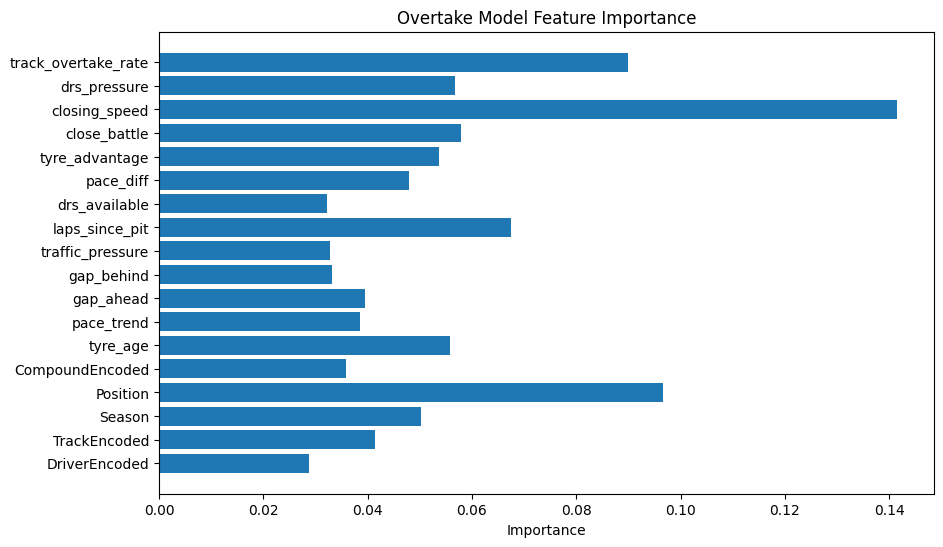

In [23]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))

plt.barh(feature_names, importance)

plt.title("Overtake Model Feature Importance")

plt.xlabel("Importance")

plt.show()

## Save Model

We save the trained model so the race simulator can load it.

In [24]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/overtake_model.pkl")

print("Overtake model saved successfully.")

Overtake model saved successfully.
